# 6. Quantitative structure models

From the points of one tree to a connected set of cylinders with volumes and
branch orders. This one starts on a synthetic tree whose every cylinder and
leaf is known, scanned as a terrestrial scanner would scan it, so the model can
be checked against the exact answer; a real tree from the Litchfield tile
follows.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.style.use("sylva.mplstyle")     # shared figure style; C0 to C7 are the Okabe-Ito colours
GROUND, WOOD, LEAF, GRASS, CONTEXT = "#997A5C", "#4D2B12", "#009E73", "#E69F00", "0.8"   # the same in every notebook
DIVERGING = "RdBu_r"                # for signed differences, centred on zero
LABELS = ListedColormap(["#332288", "#88CCEE", "#44AA99", "#117733", "#999933", "#DDCC77",
                         "#CC6677", "#882255", "#AA4499"])   # tree ids and clusters: Paul Tol's muted set

from sylva import filters, leaves, qsm

truth = synthetic.tree_model("broadleaf", dbh=0.35, height=14.0, seed=4)
print(f"truth: DBH {truth.dbh:.3f} m, height {truth.height:.1f} m, wood volume {truth.qsm.total_volume:.3f} m3 "
      f"(stem {truth.qsm.stem_volume:.3f} m3), leaf area {truth.leaf_area:.0f} m2 in {len(truth.leaves['area']):,} leaves")

truth: DBH 0.350 m, height 14.6 m, wood volume 0.738 m3 (stem 0.576 m3), leaf area 154 m2 in 39,192 leaves


`synthetic.tree_model` grows a tree from an archetype (here a broadleaf
tree whose stem forks at 80 % of its height) with pipe-model branch radii and
leaves of known size and angle; its wood is a table of cylinders, `truth.qsm`.
The tree is scanned from three positions 8 m away with the model of a RIEGL
VZ-400 (0.35 mrad beam, 7 mm exit diameter) at 0.04 degrees, with 5 mm of
range noise and mixed pixels, so the echoes carry the errors of a real scan.
They keep the true class of the surface they came from. The
[synthetic data guide](../guide/synthetic.md) describes the models.

In [2]:
parts = []
for k, (x, y) in enumerate([(8, 0), (-4, 7), (-4, -7)]):
    shots = synthetic.scan(truth.points, origin=(x, y, 1.5), resolution_deg=0.04, scanner="vz400",
                           range_noise=0.005, seed=k)
    parts.append(shots.to_pointcloud())
tree = filters.voxel_downsample(sylva.PointCloud.concatenate(parts), 0.01)
print(tree.without(*[a for a in tree.attrs if a not in ("classification", "range_spread")]))
print(f"mixed pixels (hits spread over more than 5 cm in range): {np.mean(tree.attrs['range_spread'] > 0.05):.1%} of the echoes")

PointCloud(n=1,425,706, attrs=['classification', 'range_spread'])
mixed pixels (hits spread over more than 5 cm in range): 15.4% of the echoes


## Leaf / wood separation

`wood_points` combines local anisotropy with a topological cue: points that many
shortest paths from the base to the crown pass through are wood. The echoes
know which surface they came from, so the filter can be checked both ways:
how many of the points it keeps are wood, and how many of the wood echoes it
keeps.

481,476 wood points kept: 38.0% of them on wood echoes; 98.2% of the wood echoes kept


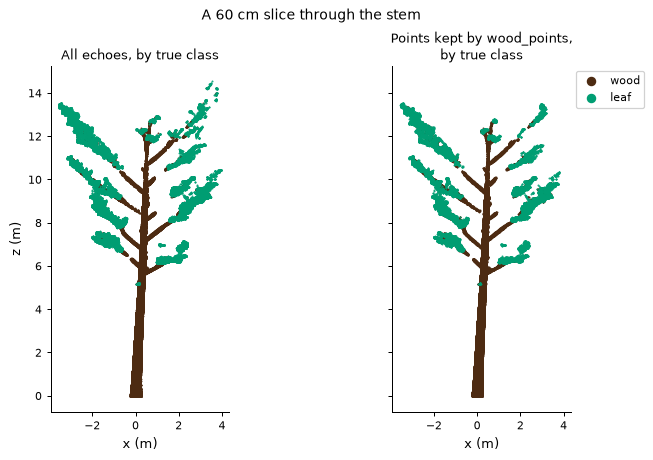

In [3]:
wood = qsm.wood_points(tree, voxel_size=0.02)
is_wood = tree.attrs["classification"] == 5
true_wood = tree[is_wood]
d, _ = filters.knn(true_wood.xyz, wood.xyz, 1)
back, _ = filters.knn(wood.xyz, true_wood.xyz, 1)
print(f"{len(wood):,} wood points kept: {np.mean(d[:, 0] < 0.02):.1%} of them on wood echoes; "
      f"{np.mean(back[:, 0] < 0.02):.1%} of the wood echoes kept")

on = d[:, 0] < 0.02                          # kept points that lie on wood echoes
fig, ax = plt.subplots(1, 2, figsize=(7.5, 5), sharex=True, sharey=True)
for a, xz, wood_mask in ((ax[0], tree, is_wood), (ax[1], wood, on)):
    slab = np.abs(xz.y - truth.base[1]) < 0.3           # a 60 cm slice through the stem
    a.scatter(xz.x[slab & wood_mask], xz.z[slab & wood_mask], s=0.3, c=WOOD, label="wood")
    a.scatter(xz.x[slab & ~wood_mask], xz.z[slab & ~wood_mask], s=0.3, c=LEAF, label="leaf")
    a.set(aspect="equal", xlabel="x (m)")
ax[0].set(title="All echoes, by true class", ylabel="z (m)")
ax[1].set(title="Points kept by wood_points,\nby true class")
fig.suptitle("A 60 cm slice through the stem")
ax[1].legend(markerscale=12, loc="upper left", bbox_to_anchor=(1.0, 1.0));

`wood_points` keeps nearly every wood echo, but most of what it keeps
are leaf echoes close to the twigs: this tree's planophile leaves sit along
its terminal branches, and from a few metres away a twig with its leaves
looks like a thicker branch.

## Cylinder model

The model is fitted to the points `wood_points` kept, and, to separate the
two sources of error, also to the true wood echoes; both are compared with
the tree's own cylinders, order by order.

In [4]:
import pandas as pd

model = qsm.build_qsm(wood, base_xy=tuple(truth.base[:2]))


def volume_by_order(m):
    v = np.pi * m.column("radius") ** 2 * m.column("length")
    order = np.minimum(m.column("branch_order").astype(int), 3)
    return np.bincount(order, weights=v, minlength=4)


on_wood = qsm.build_qsm(true_wood, base_xy=tuple(truth.base[:2]))
rows = {"QSM, wood_points": volume_by_order(model), "QSM, true wood echoes": volume_by_order(on_wood),
        "truth": volume_by_order(truth.qsm)}
table = pd.DataFrame(1000 * np.array(list(rows.values())), index=list(rows),
                     columns=["stem", "order 1", "order 2", "order 3 and up"])
table["total"] = table.sum(axis=1)
print(f"DBH: model {model.dbh:.3f} m, truth {truth.dbh:.3f} m; "
      f"fitted to points: {model.metrics()['measured_volume_fraction']:.0%} of the volume")
table.round(0).astype(int).rename_axis("wood volume (L)")

DBH: model 0.346 m, truth 0.350 m; fitted to points: 71% of the volume


,stem,order 1,order 2,order 3 and up,total
wood volume (L),,,,,
"QSM, wood_points",609,163,45,13,830
"QSM, true wood echoes",632,114,50,8,804
truth,576,102,44,16,738


The stem comes within 6 to 10 % of the truth either way, and the DBH
within 4 mm; even on the true wood echoes the model is a little too wide,
since the beam footprint and mixed pixels widen what a scan sees. The
first-order branches show where the larger error comes from: fitted to the
true wood echoes they are 12 % over, fitted to the points `wood_points` kept
60 % over, because the leaf echoes along the twigs make the branches look
thicker. The finer orders come out close to the truth, in part because the
model's taper and pipe-model priors fill in what the scans did not resolve.
Side by side:

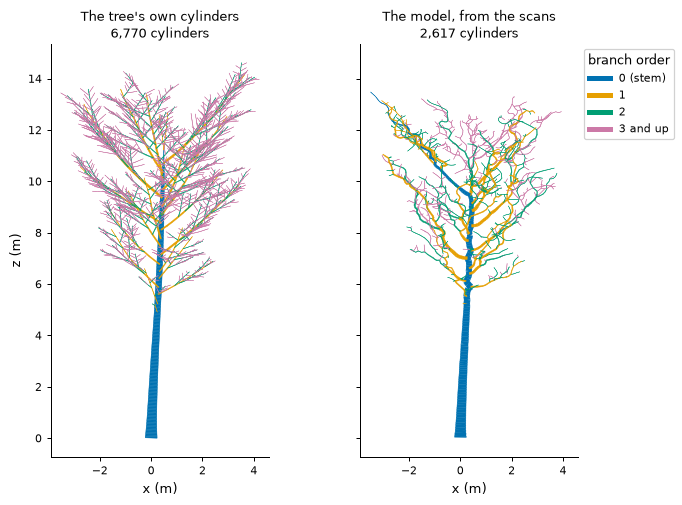

In [5]:
from matplotlib.collections import PolyCollection


ORDER_COLOURS = ["C0", "C1", "C2", "C4"]


def side_view(m, ax):
    # Each cylinder drawn at its true width: the outline of its side view, coloured by order.
    a, b = m.start[:, [0, 2]], m.end[:, [0, 2]]
    d = b - a
    n = np.c_[-d[:, 1], d[:, 0]] / np.maximum(np.hypot(*d.T), 1e-9)[:, None] * m.column("radius")[:, None]
    colours = [ORDER_COLOURS[min(o, 3)] for o in m.column("branch_order").astype(int)]
    ax.add_collection(PolyCollection(np.stack([a + n, b + n, b - n, a - n], axis=1),
                                     facecolor=colours, edgecolor=colours, lw=0.3))
    ax.autoscale_view()


fig, ax = plt.subplots(1, 2, figsize=(7.5, 5.5), sharex=True, sharey=True)
for a, m, title in ((ax[0], truth.qsm, "The tree's own cylinders"), (ax[1], model, "The model, from the scans")):
    side_view(m, a)
    a.set(aspect="equal", xlabel="x (m)", title=f"{title}\n{len(m):,} cylinders")
ax[0].set_ylabel("z (m)")
for o, name in enumerate(("0 (stem)", "1", "2", "3 and up")):
    ax[1].plot([], [], c=ORDER_COLOURS[o], lw=4, label=name)
ax[1].legend(title="branch order", loc="upper left", bbox_to_anchor=(1.0, 1.0));

## Leaf area and leaf angles

The leaf echoes give the leaf area the scans saw, voxel by voxel
(`leaves.leaf_area_density`), and the leaf angle distribution from their
local normals (`leaves.leaf_angle_distribution`); both have an exact answer
here.

In [6]:
foliage = tree[tree.attrs["classification"] == 4]
area = leaves.leaf_area_density(foliage, voxel_size=0.25)
angles = leaves.leaf_angle_distribution(foliage)
print(f"leaf area: {area.total_area:.0f} m2 seen, {truth.leaf_area:.0f} m2 true ({area.total_area / truth.leaf_area:.0%})")
print(f"mean leaf angle: {angles.mean_deg:.0f} deg measured ({angles.de_wit}), "
      f"{truth.leaf_angles().mean_deg:.0f} deg true (planophile)")

leaf area: 122 m2 seen, 154 m2 true (79%)
mean leaf angle: 46 deg measured (uniform), 27 deg true (planophile)


The scans see about four fifths of the leaf area: leaves inside the
crown are hidden behind others from all three positions. The leaf angles
come out much steeper than the truth and close to a uniform distribution:
normals estimated from a few noisy echoes on a 10 cm leaf, some of them
mixed with the leaf behind, scatter in every direction. Both numbers are
the kind of check a real scan never offers.

## A real tree, and why to check `measured_volume_fraction`

The same steps on the tallest tree of the Litchfield tile (notebook 5). The
tile is thinned to 5 cm and cut out of a decimated ray cloud, so the trunk and
branches are sampled far more thinly than a single-tree scan: most cylinders
end up interpolated rather than fitted. `metrics()["measured_volume_fraction"]`
says how much of the volume came from real fits, and it is the flag to filter
on before using QSM volumes.

In [7]:
from sylva import filters, ground, trees

plot = filters.voxel_downsample(sylva.read(DATA / "litch_tile.laz"), 0.02)
plot = ground.normalize_height(plot, ground.make_dtm(ground.classify_ground_pmf(plot), 0.5, bounds=(0, 0, 20, 20)))
stems = trees.detect_stems(plot)
stems, _ = trees.merge_branches(plot, stems)
labels = trees.segment_trees(plot, stems)
trees.tree_heights(plot, labels, stems)
stems, labels = trees.prune_trees(stems, labels, min_height=3.0)
tallest = max(stems, key=lambda t: t.height)

points = plot[labels == tallest.tree_id]
points = points[points.attrs["height"] > 0.3]      # leave the grass layer out of the base fit
real = qsm.build_qsm(qsm.wood_points(points, voxel_size=0.02), base_xy=(tallest.x, tallest.y))
print(f"detection: DBH {tallest.dbh:.3f} m, height {tallest.height:.1f} m")
print(f"QSM:       DBH {real.dbh:.3f} m, stem {real.stem_volume:.2f} m3, total {real.total_volume:.2f} m3, "
      f"{real.summary()['n_cylinders']} cylinders")
m = real.metrics()
print(f"fitted to points: {m['measured_volume_fraction']:.0%} of the volume, "
      f"{m['measured_length_fraction']:.0%} of the length")

detection: DBH 0.316 m, height 20.0 m
QSM:       DBH 0.319 m, stem 1.09 m3, total 1.67 m3, 5068 cylinders
fitted to points: 63% of the volume, 4% of the length


Two lessons. The DBHs agree (0.316 m against 0.319 m), because breast
height is where the stem is best sampled. The two fractions differ widely:
nearly two thirds of the volume lies in the trunk and the main limbs, which
were fitted to points, but only 4 % of the length was, so the finer branches
come from the taper and pipe-model priors. The stem volume is supported by
the data here; a third of the total volume, and the branch length, are not. The height cut keeps the
grass layer out of the base fit; on this tree it changes little, but tussocks
against a trunk can widen the base cylinder. Volumes are validated against felled
trees in [Benchmarks](../benchmarks/qsm.md), on single-tree clouds two orders
of magnitude denser than this tile.

## Export

A cylinder table, a raycloudtools-style tree file, and meshes for Blender / CloudCompare.

In [8]:
model.to_csv("tree_qsm.csv")
model.to_ply("tree_qsm.ply")        # faces coloured by branch order
model.to_obj("tree_qsm.obj")
qsm.QSM.from_csv("tree_qsm.csv").summary()["n_cylinders"]

2617